In [ ]:
# In colab run this cell first to setup the file structure!
%cd /content
!rm -rf MOL518-Intro-to-Data-Analysis

!git clone https://github.com/shaevitz/MOL518-Intro-to-Data-Analysis.git
%cd MOL518-Intro-to-Data-Analysis/Lecture_34

# BPY518 Lecture 34: Convolutions and Feature Extraction
Instructor: Josh Shaevitz  
Email: shaevitz@princeton.edu

## Lecture Outline
- Convolutions in 1D and 2D
- Padding and edge handling
- Derivative filters and Sobel operators
- Second derivatives and the Hessian
- Laplacian of Gaussian and blob detection
- Template matching as feature detection

Lecture 32 introduced filtering and Lecture 33 introduced frequency-based views of images. This lecture returns to the spatial domain and develops the main local operation behind many image-processing methods: the **convolution**.

Convolutions are useful because they are local, systematic, and fast. The slide deck emphasizes that they are easy to parallelize, which is one reason they show up everywhere in image processing and machine learning.

In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage, signal

plt.rcParams['figure.dpi'] = 120
plt.rcParams['image.cmap'] = 'gray'

media_dir = Path('media')

## Convolutions in 1D

For a discrete signal $f[n]$ and a kernel $h[k]$, the convolution is

$$
(f * h)[n] = \sum_k f[k] \, h[n-k].
$$

That formula looks abstract, but operationally it just means:

1. Place a small kernel over the signal.
2. Multiply the overlapping values.
3. Add them up.
4. Slide one step and repeat.

A moving average is the simplest example. If the kernel is symmetric, like `[1/3, 1/3, 1/3]`, convolution behaves exactly like a local weighted average.

Input signal: [ 2.  4.  6.  8. 10.]
Kernel: [0.33333333 0.33333333 0.33333333]
Manual moving average: [4. 6. 8.]
scipy.signal.convolve: [4. 6. 8.]


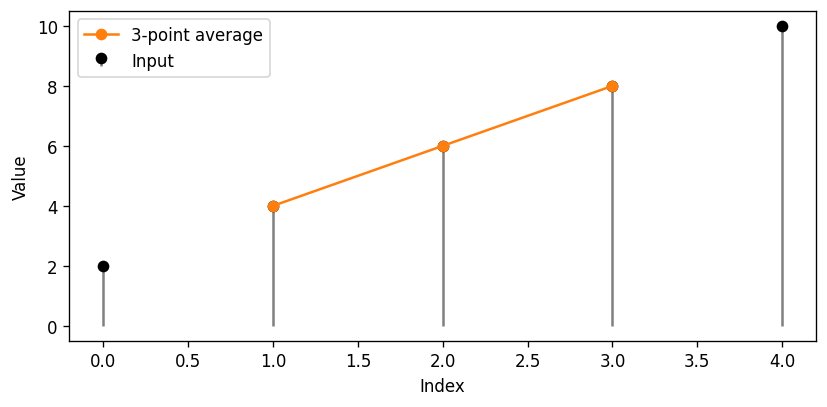

In [2]:
# Manually compute a 1D moving average and compare with scipy.
f = np.array([2, 4, 6, 8, 10], dtype=float)
h = np.array([1/3, 1/3, 1/3], dtype=float)

manual = []
for start in range(len(f) - len(h) + 1):
    window = f[start : start + len(h)]
    manual.append(np.sum(window * h))
manual = np.array(manual)

smoothed = signal.convolve(f, h, mode='valid')

print('Input signal:', f)
print('Kernel:', h)
print('Manual moving average:', manual)
print('scipy.signal.convolve:', smoothed)

x = np.arange(len(f))
plt.figure(figsize=(7, 3.5))
plt.stem(x, f, basefmt=' ', linefmt='0.5', markerfmt='ko', label='Input')
plt.plot(np.arange(1, len(f) - 1), manual, 'o-', color='C1', label='3-point average')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()

## Padding and Edge Handling

A kernel cannot be centered near the boundary unless we decide what to do beyond the image edge. That choice affects both the output size and the artifacts we may introduce.

The slide deck summarizes several common options:

![Padding options](media/padding_options.png)

In practice, `reflect` or `nearest`-style padding is often more natural for images than padding with zeros, because zero padding can create artificial dark borders.

In [3]:
# Compare padding choices for the same simple signal.
f = np.array([2, 4, 6, 8, 10], dtype=float)
kernel = np.array([1/3, 1/3, 1/3], dtype=float)

padded_zero = np.pad(f, 1, mode='constant', constant_values=0)
padded_edge = np.pad(f, 1, mode='edge')
padded_reflect = np.pad(f, 1, mode='reflect')

same_zero = signal.convolve(f, kernel, mode='same', method='direct')
same_edge = signal.convolve(padded_edge, kernel, mode='valid')
same_reflect = signal.convolve(padded_reflect, kernel, mode='valid')

print('Zero padding   ->', padded_zero, '=>', same_zero)
print('Edge padding   ->', padded_edge, '=>', same_edge)
print('Reflect padding->', padded_reflect, '=>', same_reflect)


Zero padding   -> [ 0.  2.  4.  6.  8. 10.  0.] => [2. 4. 6. 8. 6.]
Edge padding   -> [ 2.  2.  4.  6.  8. 10. 10.] => [2.66666667 4.         6.         8.         9.33333333]
Reflect padding-> [ 4.  2.  4.  6.  8. 10.  8.] => [3.33333333 4.         6.         8.         8.66666667]


## Derivatives as Convolutions

The derivative measures local slope, so it is naturally a local operation. In discrete form, a simple first-derivative filter is

$$
\frac{f(x + \Delta x) - f(x - \Delta x)}{2\Delta x},
$$

which corresponds to convolving with a kernel like `[-1, 0, 1] / 2`.

That makes derivatives another example of convolution-based filtering: we are not blurring the data anymore, we are highlighting where it changes rapidly.

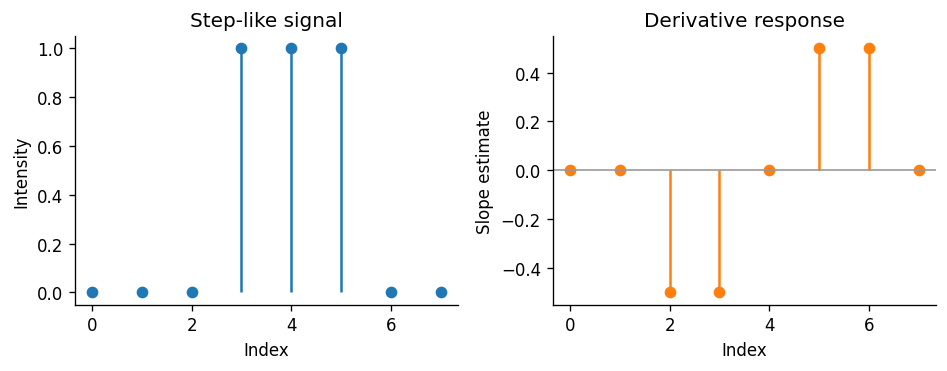

In [4]:
# Use a discrete derivative kernel to find changes in a 1D signal.
step_signal = np.array([0, 0, 0, 1, 1, 1, 0, 0], dtype=float)
derivative_kernel = np.array([-0.5, 0.0, 0.5])
gradient = signal.convolve(step_signal, derivative_kernel, mode='same')

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
axes[0].stem(np.arange(len(step_signal)), step_signal, basefmt=' ')
axes[0].set_title('Step-like signal')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Intensity')

axes[1].stem(np.arange(len(gradient)), gradient, basefmt=' ', linefmt='C1-', markerfmt='C1o')
axes[1].axhline(0, color='0.6', linewidth=1)
axes[1].set_title('Derivative response')
axes[1].set_xlabel('Index')
axes[1].set_ylabel('Slope estimate')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()

## Convolutions in 2D

For an image $I(x, y)$, a convolution applies the same local weighted sum over a 2D neighborhood. Different kernels emphasize different image properties.

Some standard examples from the slide deck are:

- **Identity kernel**: returns the original image.
- **Shift kernel**: moves the image by one pixel.
- **Mean filter**: blurs by averaging neighboring pixels.
- **Sharpening kernel**: boosts edges by subtracting a blurred version from the original.

We can demonstrate all of these on a simple synthetic image.

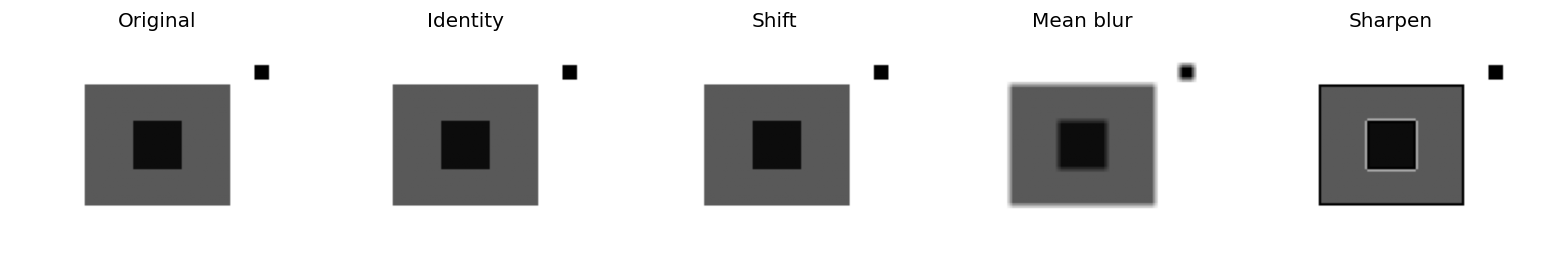

In [5]:
# Apply several 2D kernels to the same simple image.
image = np.ones((90, 120), dtype=float)
image[20:70, 30:90] = 0.35
image[35:55, 50:70] = 0.05
image[12:18, 100:106] = 0.0

identity = np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]])
shift_left = np.array([[0, 0, 0], [0, 0, 1], [0, 0, 0]])
mean_kernel = np.ones((3, 3)) / 9
sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])

outputs = [
    ('Original', image),
    ('Identity', signal.convolve2d(image, identity, mode='same', boundary='symm')),
    ('Shift', signal.convolve2d(image, shift_left, mode='same', boundary='symm')),
    ('Mean blur', signal.convolve2d(image, mean_kernel, mode='same', boundary='symm')),
    ('Sharpen', signal.convolve2d(image, sharpen_kernel, mode='same', boundary='symm')),
]

fig, axes = plt.subplots(1, 5, figsize=(13, 3))
for ax, (title, result) in zip(axes, outputs):
    ax.imshow(result, vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()

## Sobel Filters and Edge Detection

The Sobel operators combine a derivative with a small amount of smoothing. The standard kernels are

$$
G_x = \begin{bmatrix}-1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1\end{bmatrix}, \qquad
G_y = \begin{bmatrix}-1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1\end{bmatrix}.
$$

Applying these gives horizontal and vertical gradient estimates. From them we can compute the gradient magnitude and direction:

$$
|\nabla I| = \sqrt{G_x^2 + G_y^2}, \qquad \theta = \operatorname{atan2}(G_y, G_x).
$$

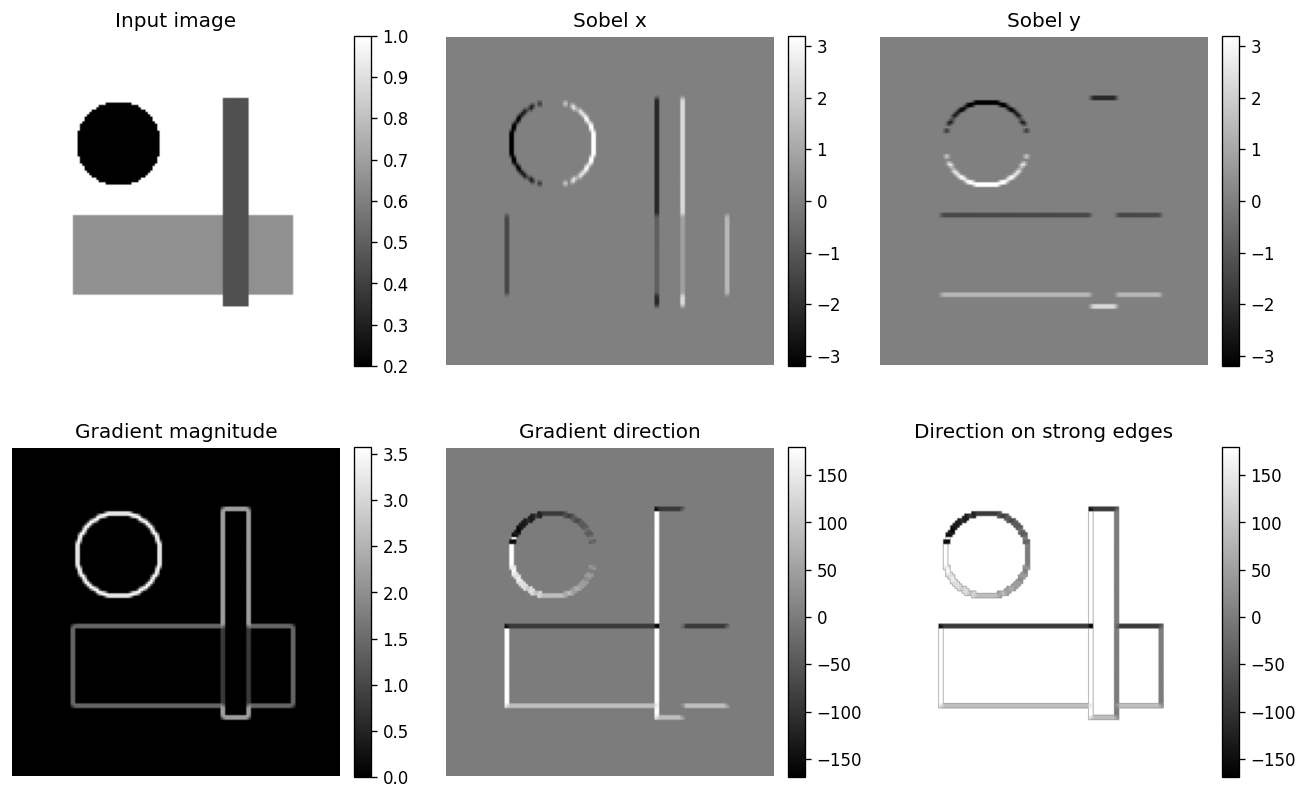

In [6]:
# Detect edges and gradient directions with Sobel filters.
yy, xx = np.mgrid[:140, :140]
edge_image = np.ones((140, 140), dtype=float)
edge_image[(xx - 45) ** 2 + (yy - 45) ** 2 < 18**2] = 0.2
edge_image[(np.abs(xx - 95) < 6) & (yy > 25) & (yy < 115)] = 0.45
edge_image[(yy > 75) & (yy < 110) & (xx > 25) & (xx < 120)] = np.minimum(edge_image[(yy > 75) & (yy < 110) & (xx > 25) & (xx < 120)], 0.65)

sobel_x = ndimage.sobel(edge_image, axis=1, mode='reflect')
sobel_y = ndimage.sobel(edge_image, axis=0, mode='reflect')
gradient_magnitude = np.hypot(sobel_x, sobel_y)
gradient_direction = np.degrees(np.arctan2(sobel_y, sobel_x))

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax, title, result in zip(
    axes.flat,
    ['Input image', 'Sobel x', 'Sobel y', 'Gradient magnitude', 'Gradient direction', 'Direction on strong edges'],
    [
        edge_image,
        sobel_x,
        sobel_y,
        gradient_magnitude,
        gradient_direction,
        np.where(gradient_magnitude > 0.4, gradient_direction, np.nan),
    ],
):
    im = ax.imshow(result)
    ax.set_title(title)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()

## Second Derivatives and the Hessian

The Hessian collects second derivatives:

$$
\mathbf{H} =
\begin{bmatrix}
I_{xx} & I_{xy} \\
I_{yx} & I_{yy}
\end{bmatrix}.
$$

Second derivatives tell us about **curvature**, not just slope. The slide deck highlights the key interpretation:

- If both Hessian eigenvalues are large and have similar magnitude, the neighborhood is blob-like.
- If one eigenvalue is large and the other is small, the neighborhood is more ridge-like or edge-like.

That is why the Hessian becomes useful for detecting blobs, ridges, and other structured features.

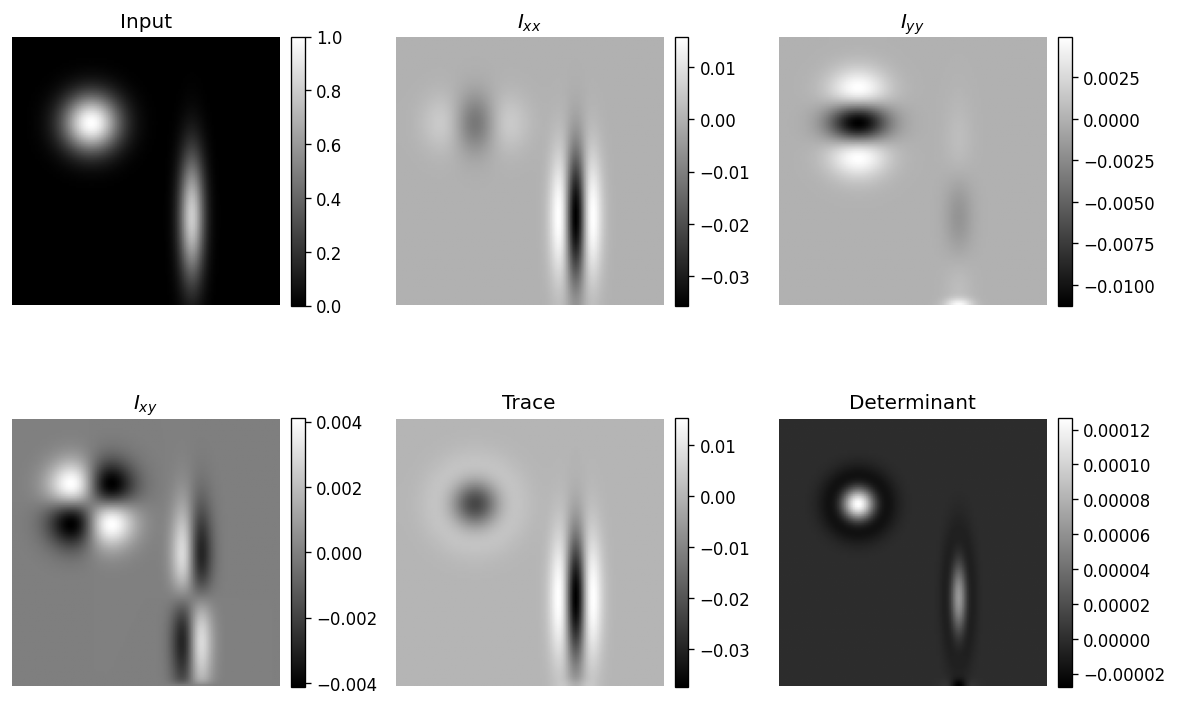

In [7]:
# Compare Hessian responses for a round blob and an elongated ridge.
shape_image = np.zeros((120, 120), dtype=float)
shape_image += np.exp(-((xx[:120, :120] - 35) ** 2 + (yy[:120, :120] - 38) ** 2) / (2 * 9**2))
shape_image += 0.8 * np.exp(-((xx[:120, :120] - 80) ** 2) / (2 * 4**2)) * np.exp(-((yy[:120, :120] - 80) ** 2) / (2 * 20**2))

Ixx = ndimage.gaussian_filter(shape_image, sigma=2, order=(0, 2))
Iyy = ndimage.gaussian_filter(shape_image, sigma=2, order=(2, 0))
Ixy = ndimage.gaussian_filter(shape_image, sigma=2, order=(1, 1))
trace = Ixx + Iyy
determinant = Ixx * Iyy - Ixy**2

fig, axes = plt.subplots(2, 3, figsize=(10, 6.5))
for ax, title, result in zip(
    axes.flat,
    ['Input', r'$I_{xx}$', r'$I_{yy}$', r'$I_{xy}$', 'Trace', 'Determinant'],
    [shape_image, Ixx, Iyy, Ixy, trace, determinant],
):
    im = ax.imshow(result)
    ax.set_title(title)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()

## Laplacian of Gaussian (Mexican Hat) Filter

The **Laplacian** adds second derivatives together, and the **Gaussian** smooths first to suppress noise. Their combination is the Laplacian of Gaussian (LoG):

$$
\nabla^2 G_\sigma * I.
$$

The LoG is often called a **Mexican hat filter** because its shape has a positive center, a negative ring, and then a decay back toward zero. This makes it sensitive to blob-like objects at a characteristic size controlled by $\sigma$.

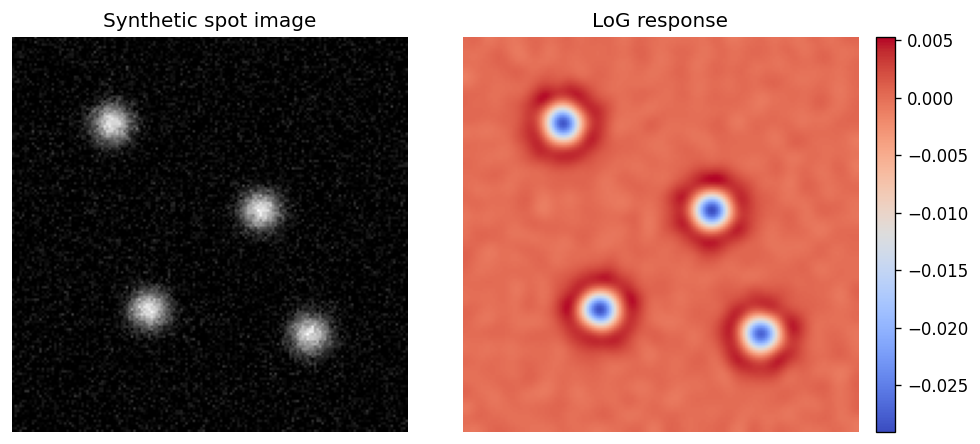

In [8]:
# Apply a Laplacian of Gaussian filter to a synthetic image with spots.
rng = np.random.default_rng(3)
spot_image = np.zeros((160, 160), dtype=float)
yy_spot, xx_spot = np.mgrid[:160, :160]
centers = [(35, 40), (70, 100), (110, 55), (120, 120)]
for cy, cx in centers:
    spot_image += np.exp(-((xx_spot - cx) ** 2 + (yy_spot - cy) ** 2) / (2 * 5.5**2))
spot_image += 0.08 * rng.normal(size=spot_image.shape)
spot_image = np.clip(spot_image, 0, None)

log_response = ndimage.gaussian_laplace(spot_image, sigma=4)

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.8))
axes[0].imshow(spot_image)
axes[0].set_title('Synthetic spot image')
axes[0].axis('off')

im = axes[1].imshow(log_response, cmap='coolwarm')
axes[1].set_title('LoG response')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()

The source deck includes a clean example of LoG-based blob detection:

![Blob detection example](media/blob_detection_example.png)

The main idea is to filter with a kernel that matches the expected blob size, then look for local extrema in the response image.

Detected coordinates (row, col):
[]


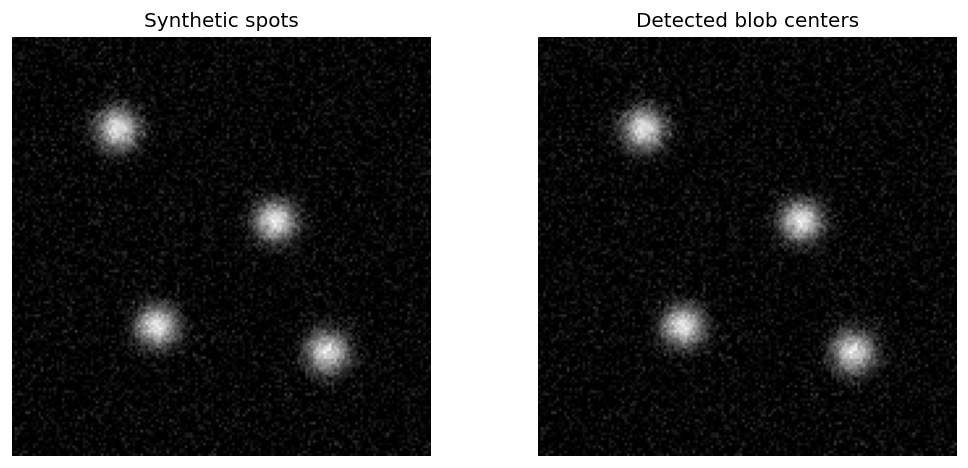

In [9]:
# Detect blob centers from the LoG response by finding local minima.
minimum_map = ndimage.minimum_filter(log_response, size=9)
blob_mask = (log_response == minimum_map) & (log_response < -0.03)
blob_positions = np.argwhere(blob_mask)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(spot_image)
axes[0].set_title('Synthetic spots')
axes[0].axis('off')

axes[1].imshow(spot_image)
axes[1].scatter(blob_positions[:, 1], blob_positions[:, 0], s=90, facecolors='none', edgecolors='C3', linewidths=2)
axes[1].set_title('Detected blob centers')
axes[1].axis('off')

plt.tight_layout()
print('Detected coordinates (row, col):')
print(blob_positions)


## Feature Detection by Template Matching

A convolution or correlation can also do **pattern matching**. If we slide a small template across a larger image and score how well it matches, peaks in the response tell us where that pattern appears.

The slide deck illustrates the idea with butterfly detection:

![Template matching example](media/template_matching_example.png)

In practice, this is the same logic behind many matched-filter and template-matching methods.

Detected template centers (row, col):
[[30 38]
 [63 86]]


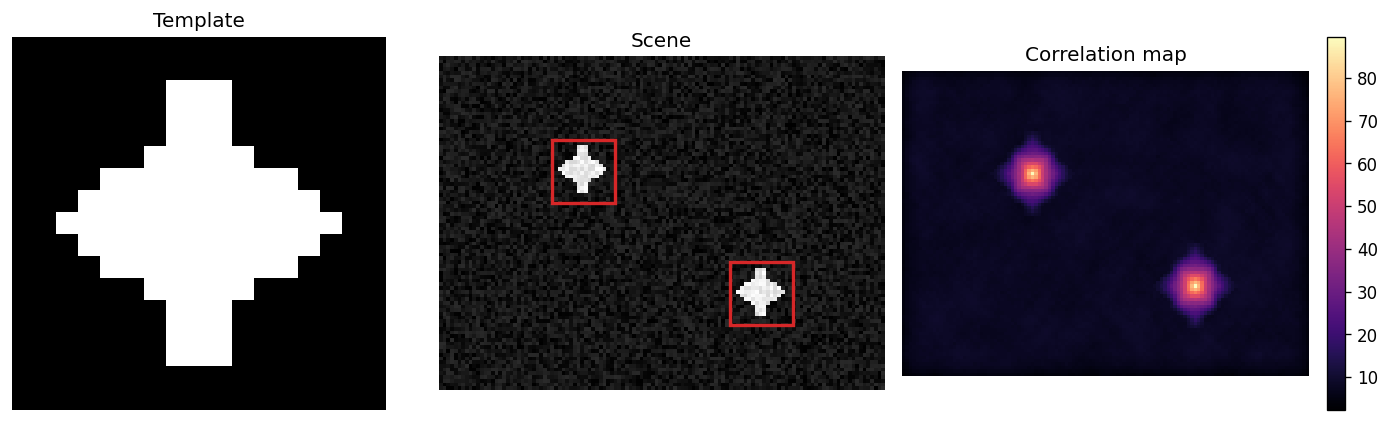

In [10]:
# Build a small synthetic template and find it in a larger scene.
def make_bowtie(size=17):
    y, x = np.mgrid[:size, :size]
    x = x - size // 2
    y = y - size // 2
    template = ((np.abs(y) <= -0.7 * np.abs(x) + 5) & (np.abs(x) <= 6)).astype(float)
    template += ((np.abs(x) <= 1) & (np.abs(y) <= 6)).astype(float)
    return np.clip(template, 0, 1)

template = make_bowtie()
scene = np.zeros((90, 120), dtype=float)
placements = [(22, 30), (55, 78)]
for r, c in placements:
    scene[r : r + template.shape[0], c : c + template.shape[1]] += template
scene += 0.2 * rng.random(scene.shape)

correlation = signal.correlate2d(scene, template, mode='same')
peak_mask = correlation == ndimage.maximum_filter(correlation, size=15)
peak_mask &= correlation > 0.75 * correlation.max()
peaks = np.argwhere(peak_mask)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
axes[0].imshow(template)
axes[0].set_title('Template')
axes[0].axis('off')

axes[1].imshow(scene)
axes[1].set_title('Scene')
axes[1].axis('off')

im = axes[2].imshow(correlation, cmap='magma')
axes[2].set_title('Correlation map')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

for r, c in peaks:
    axes[1].add_patch(plt.Rectangle((c - template.shape[1] // 2, r - template.shape[0] // 2), template.shape[1], template.shape[0], edgecolor='C3', facecolor='none', linewidth=2))

plt.tight_layout()
print('Detected template centers (row, col):')
print(peaks)


## Key Points

- A convolution is a local weighted sum that slides across a signal or image.
- Padding matters because boundaries affect the result.
- Derivative kernels and Sobel filters turn convolutions into edge detectors.
- Second derivatives and the Hessian describe curvature and help distinguish blobs from ridges.
- Laplacian-of-Gaussian filtering is a classic way to detect spot-like features.
- Template matching uses convolution-style operations for pattern detection.